# Final Project | Time Series Analysis

Topic: New York State Private Sector Compensation

Prepared By: Kyle McCormack

Date: May 6, 2027

# Setup

In [291]:
#Libraries

#Data manipulation
import pandas as pd
import numpy as np

#Utilities
import os
import json
from datetime import date
from dateutil.relativedelta import relativedelta

#visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import plotly.express as px

plt.rcParams['figure.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['grid.color'] = 'darkgray'
plt.rcParams['grid.alpha'] = 0.65
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['lines.linewidth'] = 3

palette = [
    "#300049",  # purple (primary)
    "#00838F",  # teal
    "#D47A1F",  # orange
    "#C2185B"]   # magenta

#Time series modeling & analysis
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

#Tree-based models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

In [26]:
#custom functions

#axis formatting

def thou_form(x,pos):
    return f'{x:0,.0f}'
def million_form(x,pos):
    return f'${x/1e6:0,.0f}M'

#========================================================================

#stationarity analysis
from IPython.display import display

def adf_table(series, name):
    stat, pvalue, used_lag, nobs, crit_vals, *_ = adfuller(
        np.asarray(series).astype(float),
        autolag='AIC'
    )
    out = pd.DataFrame({
        'Series': [name],
        'ADF statistic': [round(stat, 3)],
        'p value': [round(pvalue, 4)],
        'Used lags': [used_lag],
        'Critical value 5%': [round(crit_vals['5%'], 3)],
        'Decision at 5%': [
            'Stationary' if pvalue < 0.05 else 'Not stationary'
        ]}).set_index('Series')
    display(out)
    return out

def stationary_plots(x,title):
    fig, axes = plt.subplots(1,2,figsize=(12,4))
    plot_acf(x.values,ax=axes[0])
    axes[0].set_title('ACF Correlogram')
    plot_pacf(x.values,ax=axes[1])
    axes[1].set_title('PACF Correlogram')
    plt.suptitle(title)
    plt.show();

#========================================================================

#ETS modeling
def ets_model(
    train_series: pd.Series,
    horizon: int,
    trend: str | None,
    damped_trend: bool,
):
    """
    Fit a single ETS model and return:
    1) forecast series,
    2) fitted parameters,
    3) fitted model object.
    """
    model = ExponentialSmoothing(
        train_series,
        trend=trend,
        damped_trend=damped_trend,
        seasonal=None,
    )
    fit_model = model.fit(optimized=True)
    forecast = fit_model.forecast(horizon)  # keeps aligned future index when freq is set
    model_params = fit_model.params

    return forecast, model_params, fit_model


In [ ]:
#shorten industry descriptions
industry_map = {
'Wholesale trade':'Wholesale trade',
 'Retail trade': 'Retail trade',
 'Transportation and warehousing':'Transport',
 'Information':'Technology',
 'Finance and insurance':'Finance',
 'Real estate and rental and leasing':'Real estate',
 'Professional, scientific, and technical services':'Professional/Technical services',
 'Management of companies and enterprises':'Management',
 'Administrative and support and waste management and remediation services':'Admin/support services',
 'Educational services':'Education',
 'svcs care and social assistance':'svcs care',
 'Arts, entertainment, and recreation':'Entertainment',
 'Accommodation and food services':'Hospitality',
 'Other services (except government and government enterprises)':'Other private services'
 }

In [5]:
#data load

df = (pd.read_csv('data.csv',skiprows=3)
    .dropna(subset=['Description'])
    .drop(columns=['GeoFIPS','GeoName'])
    .set_index('LineCode')
    .melt(id_vars=['Description'],
        var_name = 'period',
        value_name='compensation',
        ignore_index = False)
        )
df.index.name = 'code'
df.columns = ['industry','period','compensation']
df['industry'] = df['industry'].str.strip().map(industry_map)
df['period'] = (df['period']
    .str.replace(
        r'(\d{4}):Q1', 
        r'\1-01-01',
        regex=True
    )
    .str.replace(
        r'(\d{4}):Q2', 
        r'\1-04-01',
        regex=True
    )
    .str.replace(
        r'(\d{4}):Q3', 
        r'\1-07-01',
        regex=True
    )
    .str.replace(
        r'(\d{4}):Q4', 
        r'\1-10-01',
        regex=True
    )
)
df['period'] = pd.to_datetime(df['period'], format='%Y-%m-%d')
df['year'] = df['period'].dt.year
df.head()

,industry,period,compensation,year
code,,,,
600.0,Wholesale trade,1998-01-01,21243968.0,1998
700.0,Retail trade,1998-01-01,21947724.0,1998
800.0,Transport,1998-01-01,9582764.0,1998
900.0,Technology,1998-01-01,19137684.0,1998
1000.0,Finance,1998-01-01,62067196.0,1998


# Exploratory Data Analysis

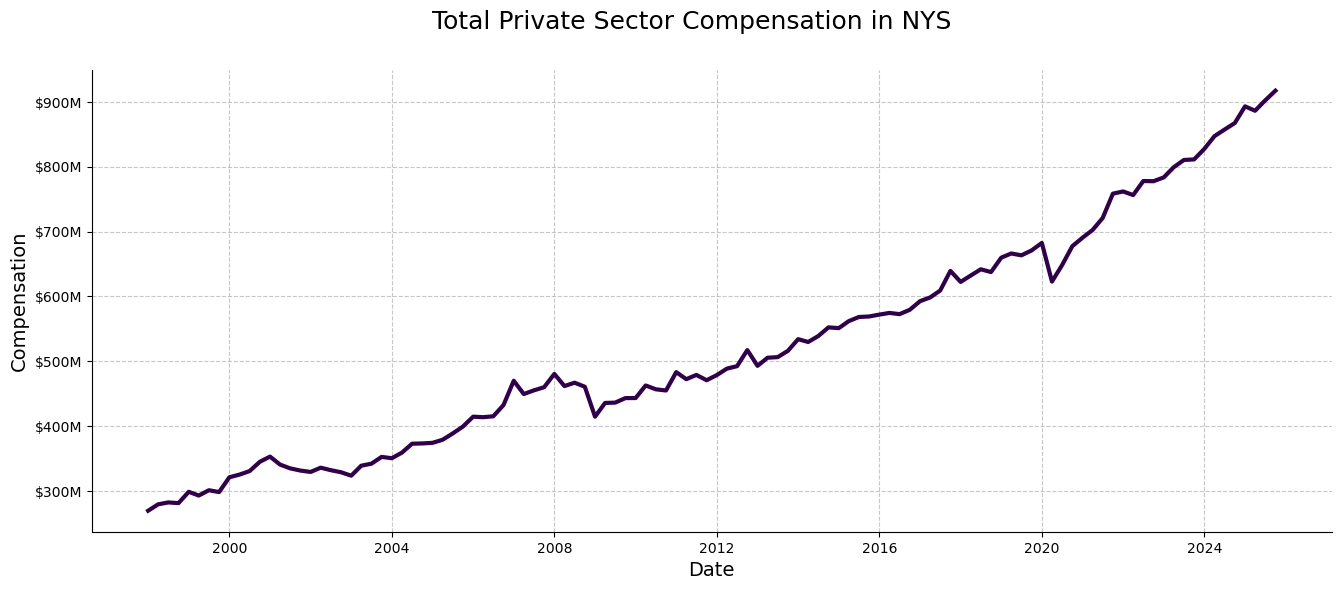

In [120]:
plt.figure(figsize=(16,6))
sns.lineplot(data=df,
             x='period',
             y='compensation',
             estimator='sum',
             errorbar=None,
             color = palette[0]
             )
plt.suptitle('Total Private Sector Compensation in NYS')
plt.xlabel('Date')
plt.ylabel('Compensation')
plt.grid()
plt.gca().yaxis.set_major_formatter(million_form)
plt.show();

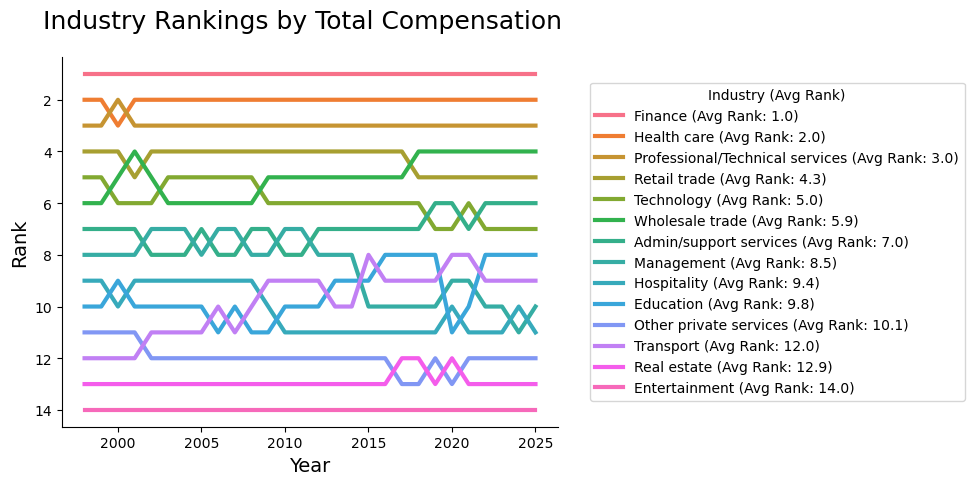

In [121]:
#Industry rank by year

year_df = (
    df[['industry', 'year', 'compensation']]
    .groupby(['year', 'industry'], as_index=False)
    .agg(compensation=('compensation', 'sum'))
)
year_df['rank'] = (
    year_df
    .groupby('year')['compensation']
    .rank(method='dense', ascending=False)
)
year_df = year_df.sort_values(by=['year','compensation'],ascending=[True,False])


avg_rank_dict = (year_df.groupby('industry')['rank']
                 .mean()
                 .round(1)
                 .sort_values()
                 .to_dict()
                 )
#Plot
sns.lineplot(data=year_df,
             x='year',
             y='rank',
             hue='industry',
             markers=True
)

#Legend
handles, labels = plt.gca().get_legend_handles_labels()
# Map industry name -> handle
handle_dict = dict(zip(labels, handles))

# Sort industries by average rank
sorted_industries = sorted(
    avg_rank_dict, #type: ignore
    key=avg_rank_dict.get #type:ignore
)

# Rebuild ordered handles and labels
sorted_handles = [
    handle_dict[ind]
    for ind in sorted_industries
]

sorted_labels = [
    f'{ind} (Avg Rank: {avg_rank_dict[ind]:.1f})'
    for ind in sorted_industries
]
plt.legend(handles=handles,
           labels=sorted_labels,
           title='Industry (Avg Rank)',
           bbox_to_anchor=(1.05,0.95))

#axes
plt.gca().invert_yaxis()

#Labels
plt.ylabel('Rank')
plt.xlabel('Year')
plt.suptitle('Industry Rankings by Total Compensation')
plt.show();

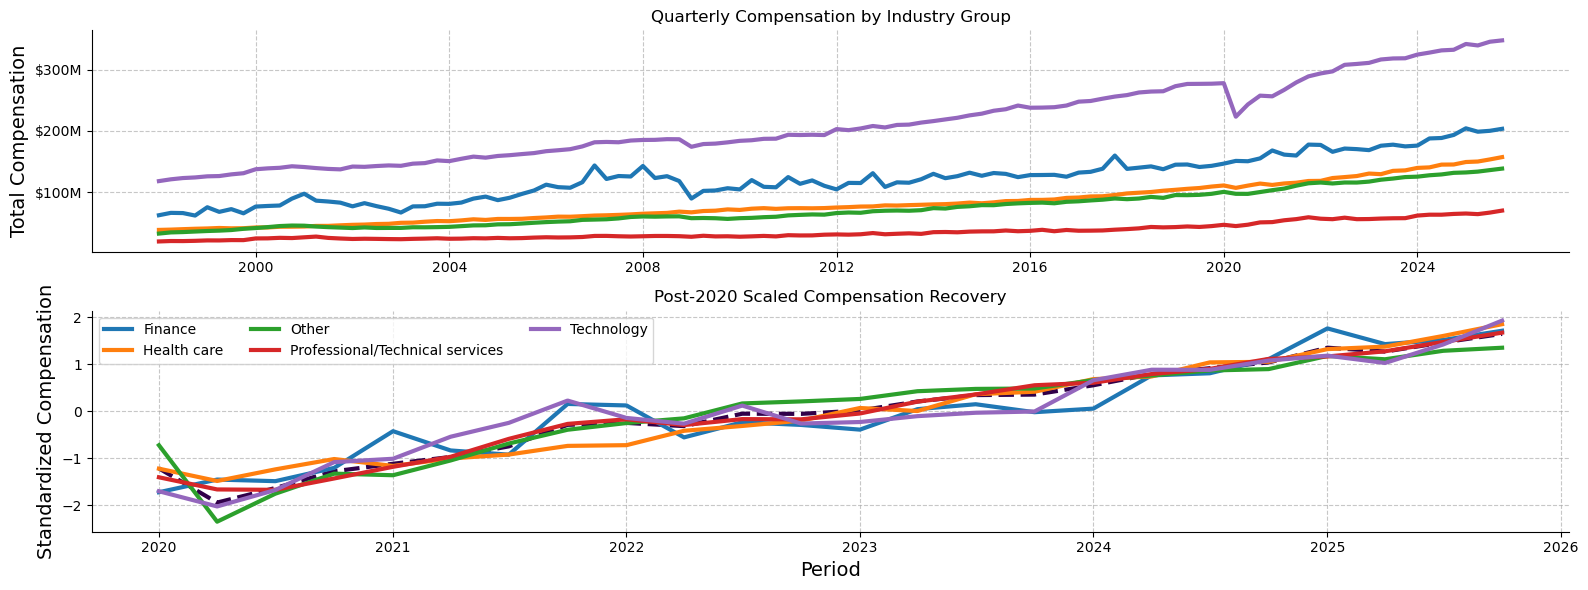

In [ ]:
top_industries = ['Finance','Health care','Professional/Technical services','Technology']
df['industry_group'] = df['industry'].apply(lambda x:
                                            x if x in top_industries else 'Other')


fig,axes = plt.subplots(2,1,figsize=(16,6))

#Plot 1 -- total compensation levels
for group in (top_industries + ['Other']):
    temp_df = (df.loc[df['industry_group']==group]
               .groupby('period',as_index=False)['compensation']
               .sum()
               )
    axes[0].plot(temp_df['period'],
             temp_df['compensation'],
             label=group
            )
axes[0].set_title('Quarterly Compensation by Industry Group')
axes[0].yaxis.set_major_formatter(million_form)
axes[0].set_ylabel('Total Compensation')
axes[0].grid()
#--------------------------------------------------
#Plot 2 -- Series since pre-COVID

from sklearn.preprocessing import StandardScaler
plot_df = (df.loc[df['period'] >= pd.Timestamp('2020-01-01')]
      .groupby(['period', 'industry_group'], as_index=False)['compensation']
      .sum()
)

plot_df['scaled_comp'] = (
    plot_df.groupby('industry_group')['compensation']
           .transform(lambda x: StandardScaler().fit_transform(x.to_numpy().reshape(-1, 1)).ravel())
)

total_plot_df = (
    df.loc[df['period'] >= pd.Timestamp('2020-01-01')]
      .groupby('period', as_index=False)['compensation']
      .sum()
)

total_plot_df['scaled_comp'] = (
    StandardScaler()
    .fit_transform(total_plot_df[['compensation']]) #type: ignore
    .ravel()
)

sns.lineplot(data=total_plot_df,#type: ignore
             x='period',
             y='scaled_comp',
             c=palette[0],
             linestyle='--',
             estimator='sum',
             ax=axes[1]
             )
sns.lineplot(data=plot_df,#type: ignore
             x='period',
             y='scaled_comp',
             hue='industry_group',
             estimator='sum',
             errorbar=None,
             ax=axes[1])

axes[1].set_title('Post-2020 Scaled Compensation Recovery')
axes[1].set_ylabel('Standardized Compensation')
axes[1].set_xlabel('Period')
axes[1].grid()
axes[1].legend(ncols=3)

plt.tight_layout()
#plt.suptitle('NYS Industry Compensation over Time')
plt.show();

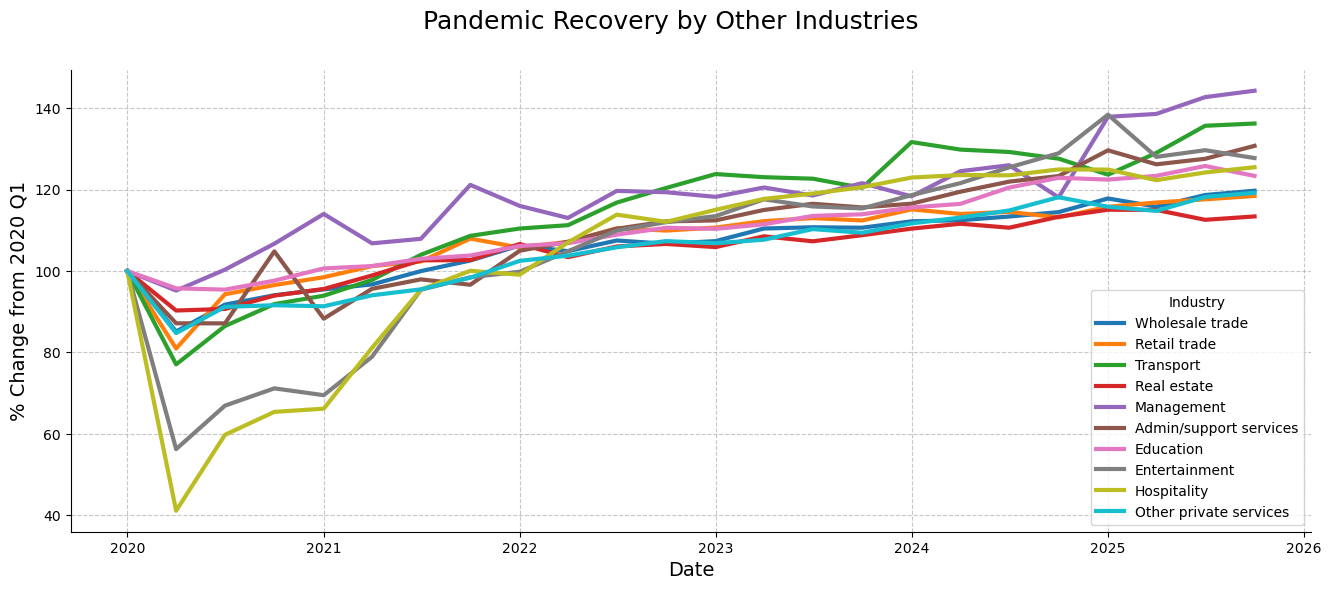

In [105]:
plot_df = df.loc[(df['period'] >= pd.Timestamp(date(2020,1,1))) &
                  (df['industry_group']=='Other')]
reference_date = pd.Timestamp('2020-01-01')

precovid = (plot_df.loc[plot_df['period']==reference_date,
                       ['industry','compensation']]
                       .rename(columns={'compensation':'precovid'})
            )
plot_df = plot_df.merge(precovid,on='industry',how='left')
plot_df['change'] = np.round((plot_df['compensation'] / plot_df['precovid'])*100,2)

plt.figure(figsize=(16,6))

sns.lineplot(data=plot_df,
             x=plot_df['period'],
             y='change',
             estimator='sum',
             hue='industry')
plt.suptitle('Pandemic Recovery by Other Industries')
plt.grid()
plt.ylabel('% Change from 2020 Q1')
plt.xlabel('Date')
plt.legend(title='Industry')
plt.show();

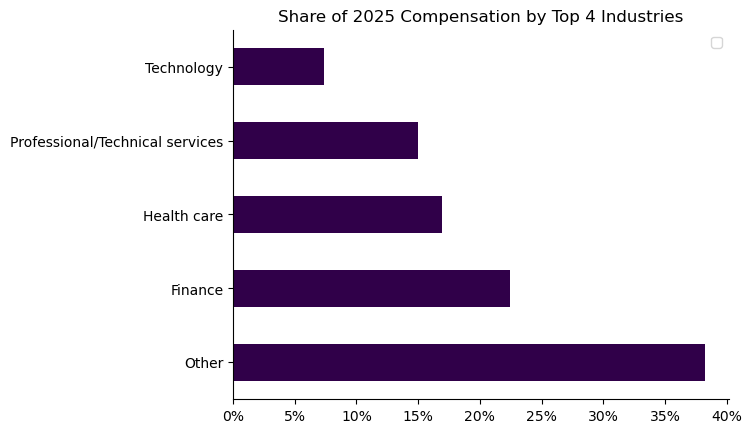

In [123]:
df2025 = (df
          .loc[df['period'].dt.year == 2025,
               ['industry_group','compensation']]
               .groupby('industry_group')
               .sum()
               .sort_values(by='compensation',
                            ascending=False))
(df2025/df2025.sum()).plot(kind='barh',color=palette[0],title='Share of 2025 Compensation by Top 4 Industries')
plt.legend([])
plt.ylabel('')
plt.xlabel('')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.0%}'))
plt.show();

# Modeling

In [132]:
#series
series_index = pd.date_range(df['period'].min(),
                             end=df['period'].max(),
                             freq='QS')

finance = pd.Series(df.loc[df['industry']==top_industries[0],
                           'compensation']
                        .reset_index(drop=True).values,
                    index=series_index,
                    name='finance'
                    )
health = pd.Series(df.loc[df['industry']==top_industries[1],
                          'compensation']
                    .reset_index(drop=True).values,
                    index=series_index,
                    name='health'
                    )
prof_svcs = pd.Series(df.loc[df['industry']==top_industries[2],
                             'compensation']
                        .reset_index(drop=True).values,
                        index=series_index,
                        name='prof_svcs'
                    )
tech = pd.Series(df.loc[df['industry']==top_industries[3],
                        'compensation']
                    .reset_index(drop=True).values,
                    index=series_index,
                    name='tech'
                )

series_list = [finance,health,prof_svcs,tech]


In [305]:
#training/testing periods
test_length = 20

def train_test_split(series, test_n = test_length):
    train = series.iloc[:-test_n]
    test = series.iloc[-test_n:]
    return train, test

def train_test_split_diff(series, test_n = test_length):
    series = series.diff().dropna()
    train = series.iloc[:-test_n]
    test = series.iloc[-test_n:]
    return train, test

#### Series and their Differences


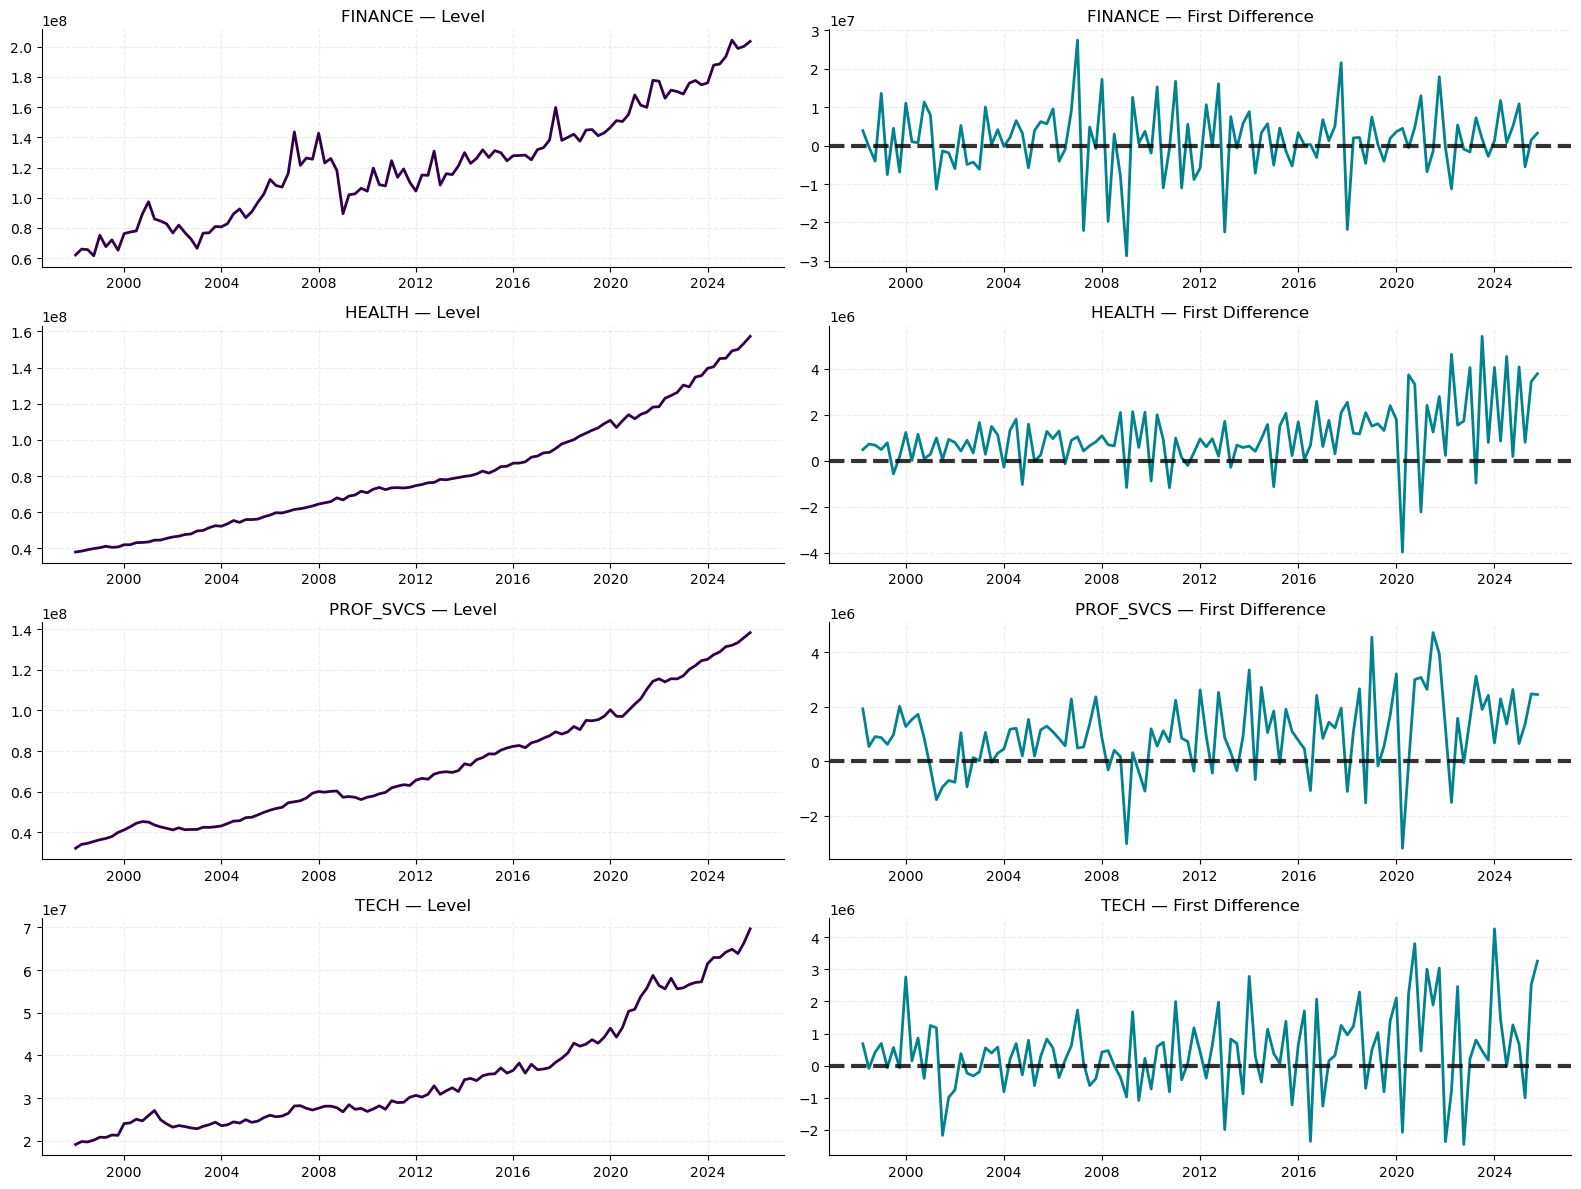

In [321]:
fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=False)

for i, s in enumerate(series_list):

    # Left column: level series
    axes[i, 0].plot(
        s.index,
        s.values,
        linewidth=2,
        c = palette[0]
    )

    axes[i, 0].set_title(f'{s.name.upper()} — Level')
    axes[i, 0].grid(alpha=0.2)

    # Right column: first difference
    diff_s = s.diff().dropna()

    axes[i, 1].plot(
        diff_s.index,
        diff_s.values,
        linewidth=2,
        color=palette[1]
    )

    axes[i, 1].axhline(
        0,
        linestyle='--',
        color='black',
        alpha=0.8
    )

    axes[i, 1].set_title(f'{s.name.upper()} — First Difference')
    axes[i, 1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

<Axes: >

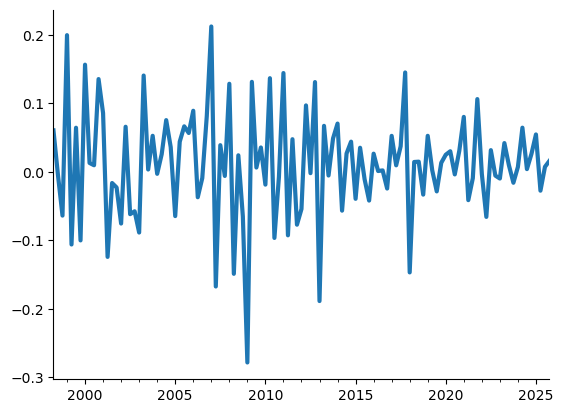

In [322]:
test_fin = np.log(finance).diff().dropna()

test_fin.plot()

## Exponential Smoothing Models

In [9]:
def plot_ets_forecast(series, forecast, fitted_model, title='ETS Forecast'):
    plt.figure(figsize=(12, 4))
    plt.plot(series,
             c=palette[0],
             label='Actuals')
    plt.plot(fitted_model.fittedvalues,
             c=palette[1],
             label='Fitted Values')
    plt.plot(forecast,
             c=palette[2],
             linestyle='--',
             label='Forecast')
    plt.gca().yaxis.set_major_formatter(million_form)
    plt.grid()
    plt.suptitle(title)
    plt.legend()
    plt.show()

### Model Fit/Train

In [308]:
#Holt models
holt_models = {}
holt_results = {}
holt_errors = {}

for s in series_list:
    series_label = s.name
    s_train, s_test = train_test_split(s,test_length)

    #fit the model
    s_holt = Holt(s_train,initialization_method='estimated')
    s_fit = s_holt.fit()
    s_holt_pred = s_fit.forecast(test_length)

    #store model results
    holt_models[series_label] = s_fit
    holt_results[series_label] = {
        'fitted_vals':s_fit.fittedvalues,
        'forecast':s_holt_pred
        }
    #calculate error
    mae = mean_absolute_error(s_test,s_holt_pred)
    mape = mean_absolute_percentage_error(s_test,s_holt_pred)
    r2 = r2_score(s_test,s_holt_pred)
    holt_errors[series_label] = {
        'mae':mae,
        'mape':mape,
        'r2':r2
    }

holt_forecasts = pd.DataFrame({
    industry: results['forecast']
    for industry, results in holt_results.items()
})
holt_fitted = pd.DataFrame({
    industry: results['fitted_vals']
    for industry, results in holt_results.items()
})

holt_errors = pd.DataFrame(holt_errors).T

c:\Users\kpmcc\anaconda3\envs\grad_school\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [309]:
#ETS Models

ets_models = {}
ets_results = {}
ets_errors = {}

for s in series_list:
    series_label = s.name
    s_train, s_test = train_test_split(s,test_length)

    #calculation
    s_forecast, s_params, s_model = ets_model(train_series = s_train,
                                              horizon = test_length,
                                              trend = 'mul',
                                              damped_trend=False
                                              )
    #storage
    ets_models[series_label] = s_model
    ets_results[series_label] = s_forecast

    #error calculation
    mae = mean_absolute_error(s_test,s_forecast)
    mape = mean_absolute_percentage_error(s_test,s_forecast)
    r2 = r2_score(s_test,s_forecast)
    ets_errors[series_label] = {
        'mae':mae,
        'mape':mape,
        'r2':r2
    }

ets_forecasts = pd.DataFrame(ets_results)
ets_errors = pd.DataFrame(ets_errors).T


In [310]:
print('Error Metrics for Holt\'s Method')
display((holt_errors.style.format({ #type: ignore
    'mae':'{:0,.0f}',
    'mape':'{:.2%}',
    'r2':'{:0.3f}'
})))
print('='*100)
print('Error Metrics for Multiplicative ETS Model')
ets_errors.style.format({ #type: ignore
    'mae':'{:0,.0f}',
    'mape':'{:.2%}',
    'r2':'{:0.3f}'
})

Error Metrics for Holt's Method


,mae,mape,r2
finance,"11,550,223",6.19%,-0.008
health,"7,201,962",5.06%,0.560
prof_svcs,"14,007,807",11.22%,-1.388
tech,"2,385,607",3.97%,0.620


Error Metrics for Multiplicative ETS Model


,mae,mape,r2
finance,"13,345,020",7.17%,-0.277
health,"5,556,381",3.93%,0.747
prof_svcs,"8,563,705",6.93%,0.160
tech,"3,736,250",6.16%,0.202


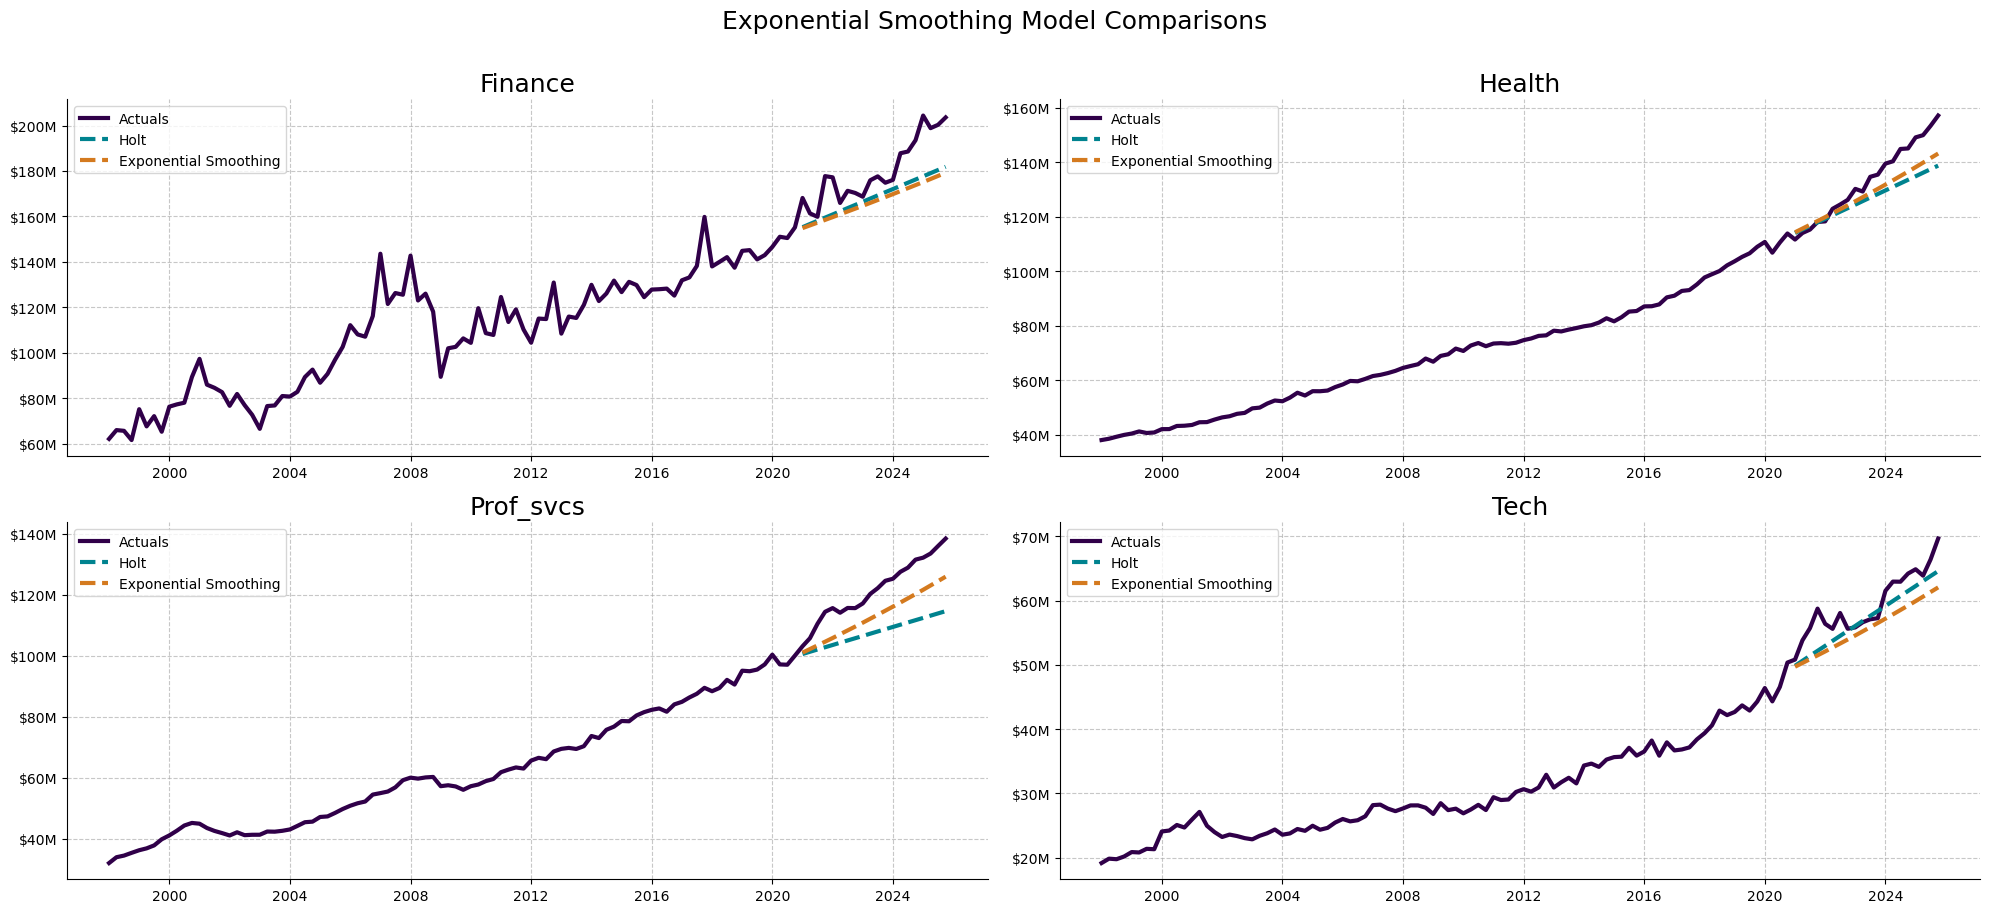

In [ ]:
#plot_ets_forecast(finance,finance_fc,finance_model,title='Finance Forecast')

fig,axes = plt.subplots(2,2,figsize=(20,9))
axes = axes.ravel()

for s, ax in zip(series_list,axes):
    s_label = s.name
    ax.plot(s,
                c=palette[0],
                label='Actuals')
    ax.plot(holt_forecasts[s_label],
                c=palette[1],
                linestyle='--',
                label='Holt'
                )
    ax.plot(ets_forecasts[s_label],
                c=palette[2],
                linestyle='--',
                label='Exponential Smoothing'
                )
    ax.set_title(s_label.capitalize(), #type: ignore
                 fontsize=18)
    ax.grid()
    ax.legend()
    ax.yaxis.set_major_formatter(million_form)

plt.suptitle('Exponential Smoothing Model Comparisons',
             y=1.01)
plt.tight_layout()
plt.show();

## ARIMA Modeling

### Stationarity Check

,ADF statistic,p value,Used lags,Critical value 5%,Decision at 5%
Series,,,,,
Finance,-4.856,0.0,8,-2.89,Stationary


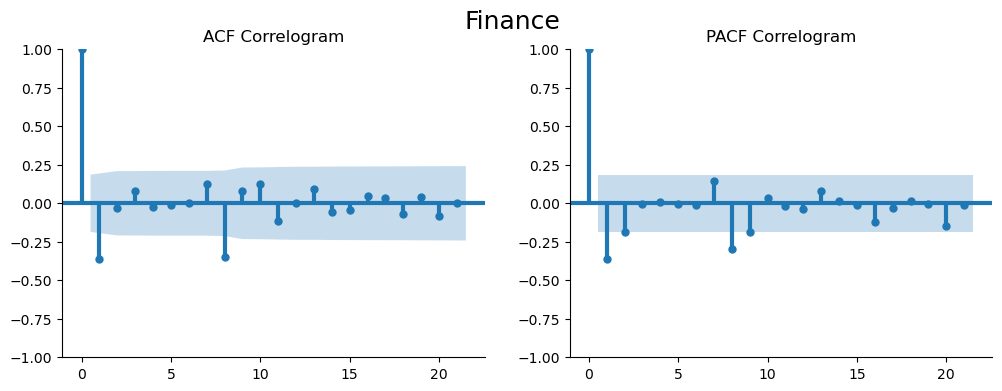

,ADF statistic,p value,Used lags,Critical value 5%,Decision at 5%
Series,,,,,
Health care,-0.687,0.85,4,-2.889,Not stationary


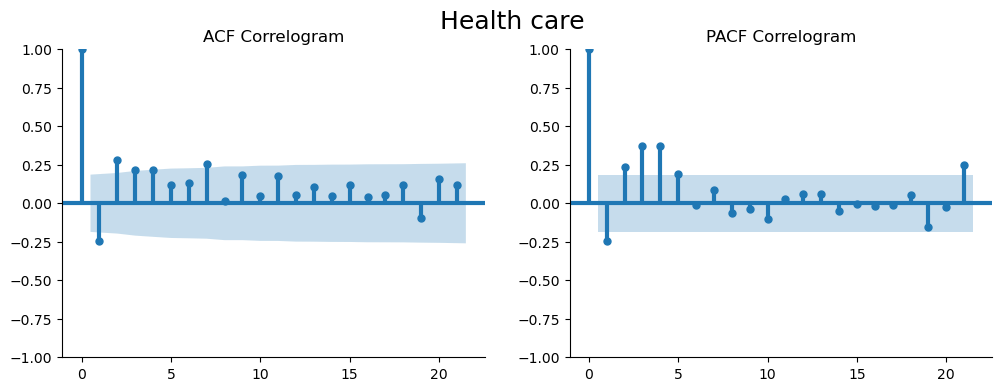

,ADF statistic,p value,Used lags,Critical value 5%,Decision at 5%
Series,,,,,
Professional/Technical Services,-2.615,0.0899,6,-2.89,Not stationary


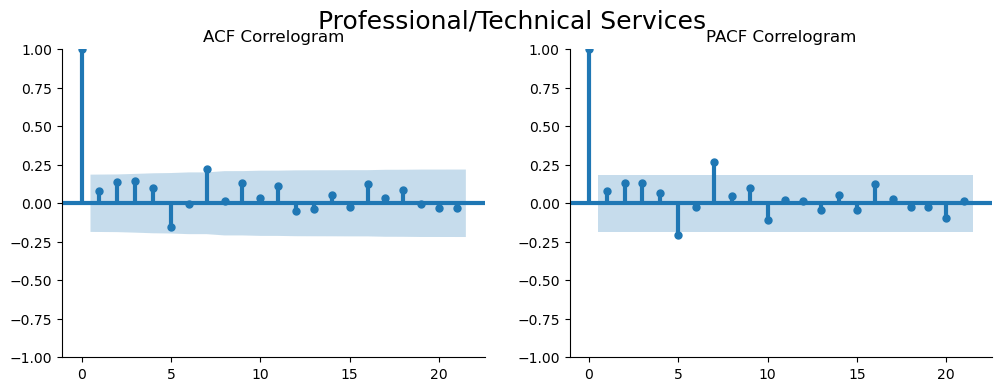

,ADF statistic,p value,Used lags,Critical value 5%,Decision at 5%
Series,,,,,
Technology,-4.473,0.0002,2,-2.889,Stationary


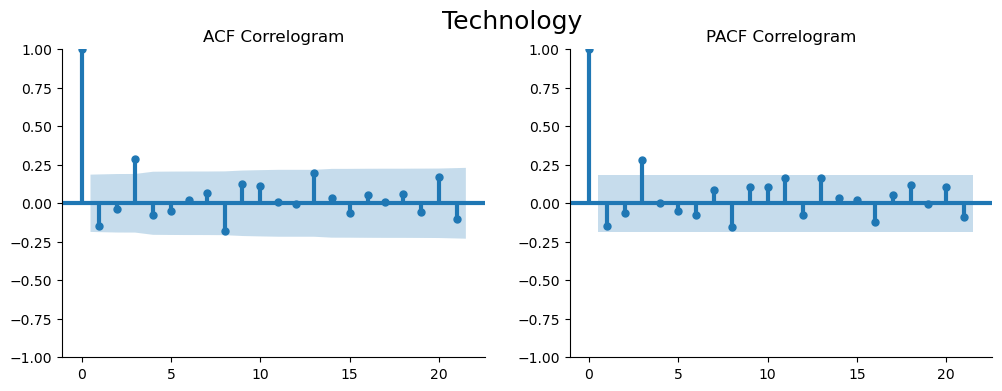

In [313]:
adf_table(fin_diff,'Finance')
stationary_plots(fin_diff,'Finance')
#=======================================
adf_table(health_diff,'Health care')
stationary_plots(health_diff,'Health care')
#=======================================
adf_table(svcs_diff,'Professional/Technical Services')
stationary_plots(svcs_diff,'Professional/Technical Services')
#=======================================
adf_table(tech_diff,'Technology')
stationary_plots(tech_diff,'Technology')

### Model Fit/Train

Candidate ARIMA specifications were screened using information criteria and Ljung-Box residual diagnostics. Only models exhibiting residuals consistent with white noise behavior and successful numerical convergence were retained for forecast evaluation.

In [314]:
#ARIMA helpers
arima_fits = {}
evals = []

#Candidate order for ARIMA model
candidate_orders = {'finance':[(1,1,1),(1,1,0),(1,1,2),(0,1,2)],
                    'health':[(4,1,2),(3,1,3),(1,1,1),(5,1,0)],
                    'prof_svcs':[(1,1,1),(2,1,1),(0,1,1)],
                    'tech':[(1,1,0),(0,1,1),(0,2,2),(3,1,0),(3,1,3)]
                    }
#Loop and fit models
for s in series_list:
    s_label = s.name
    s_train, s_test = train_test_split(s, test_length)
    selected_orders = candidate_orders[s_label] #type: ignore
    
    series_fits = {}
    for order in selected_orders:
        result = ARIMA(s_train,
                        order = order,
                        enforce_stationarity=True).fit()
        series_fits[order] = result
        lb = acorr_ljungbox(result.resid.iloc[1:],
                            lags=[10],
                            return_df = True)
        evals.append({
            'series':s_label,
            'order':order,
            'AIC': round(result.aic, 2),
            'BIC': round(result.bic, 2),
            'Ljung Box p value at lag 10': round(lb['lb_pvalue'].iloc[0], 4),
        })

eval_df = pd.DataFrame(evals).sort_values(['series','BIC', 'AIC']).reset_index(drop=True)
display(
    eval_df
    .set_index(['series', 'order'])
    .sort_index()
)

c:\Users\kpmcc\anaconda3\envs\grad_school\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\kpmcc\anaconda3\envs\grad_school\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\kpmcc\anaconda3\envs\grad_school\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\kpmcc\anaconda3\envs\grad_school\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-s

AIC      BIC  Ljung Box p value at lag 10
series    order                                                   
finance   (0, 1, 2)  3175.52  3183.05                       0.0607
          (1, 1, 0)  3174.01  3179.03                       0.0362
          (1, 1, 1)  3175.63  3183.17                       0.0608
          (1, 1, 2)  3175.83  3185.88                       0.0960
health    (1, 1, 1)  2787.43  2794.97                       0.0454
          (3, 1, 3)  2784.94  2802.52                       0.2401
          (4, 1, 2)  2796.20  2813.78                       0.0698
          (5, 1, 0)  2844.49  2859.55                       0.3371
prof_svcs (0, 1, 1)  2843.58  2848.60                       0.0200
          (1, 1, 1)  2822.37  2829.90                       0.0527
          (2, 1, 1)  2824.14  2834.18                       0.0396
tech      (0, 1, 1)  2802.63  2807.65                       0.0047
          (0, 2, 2)  2814.72  2822.22                       0.1420
          (1, 1, 0)  2802.65  2807.67                       0.0047
          (3, 1, 0)  2803.80  2813.84                       0.0333
          (3, 1, 3)  2800.28  2817.86                       0.0024

In [315]:
chosen_orders ={'finance':(0,1,2),
                'health':(3,1,3),
                'prof_svcs':(1,1,1),
                'tech':(0,2,2)
                }

arima_models = {}
arima_forecasts = {}
arima_errors = {}
for s in series_list:
    s_label = s.name
    s_train, s_test = train_test_split(s, test_length)
    selected_orders = candidate_orders[s_label] #type: ignore
    model = ARIMA(s_train,
                  order=order).fit()
    
    pred = model.get_forecast(steps=test_length)
    s_forecast = pred.predicted_mean

    arima_models[s_label] = model
    arima_forecasts[s_label] = s_forecast

    #error calculation
    mae = mean_absolute_error(s_test,s_forecast)
    mape = mean_absolute_percentage_error(s_test,s_forecast)
    r2 = r2_score(s_test,s_forecast)
    arima_errors[s_label] = {
        'mae':mae,
        'mape':mape,
        'r2':r2
    }

arima_fc_df = pd.DataFrame(arima_forecasts)
arima_error_df = pd.DataFrame(arima_errors).T

c:\Users\kpmcc\anaconda3\envs\grad_school\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\kpmcc\anaconda3\envs\grad_school\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\kpmcc\anaconda3\envs\grad_school\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\kpmcc\anaconda3\envs\grad_school\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary startin

### ARIMA Error

In [316]:
#errors

display(arima_error_df
        .style
        .format({
            'mae':'{0:,.0f}',
            'mape':'{:0.2%}',
            'r2':'{:0.2f}'
        }))

,mae,mape,r2
finance,"26,611,657",14.33%,-3.75
health,"10,866,551",7.63%,0.01
prof_svcs,"14,031,785",11.24%,-1.40
tech,"5,588,513",9.07%,-0.83


### Residuals

RESIDUALS FOR FINANCE INDUSTRY


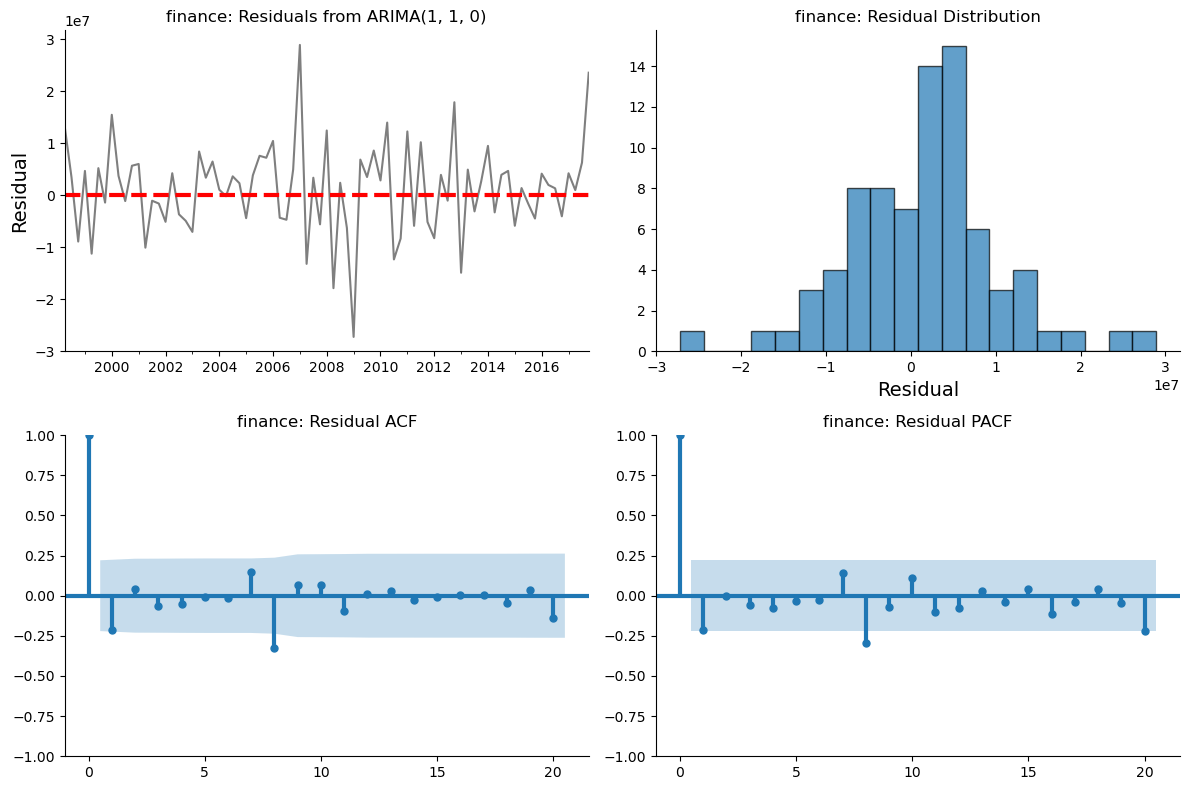

RESIDUALS FOR HEALTH INDUSTRY


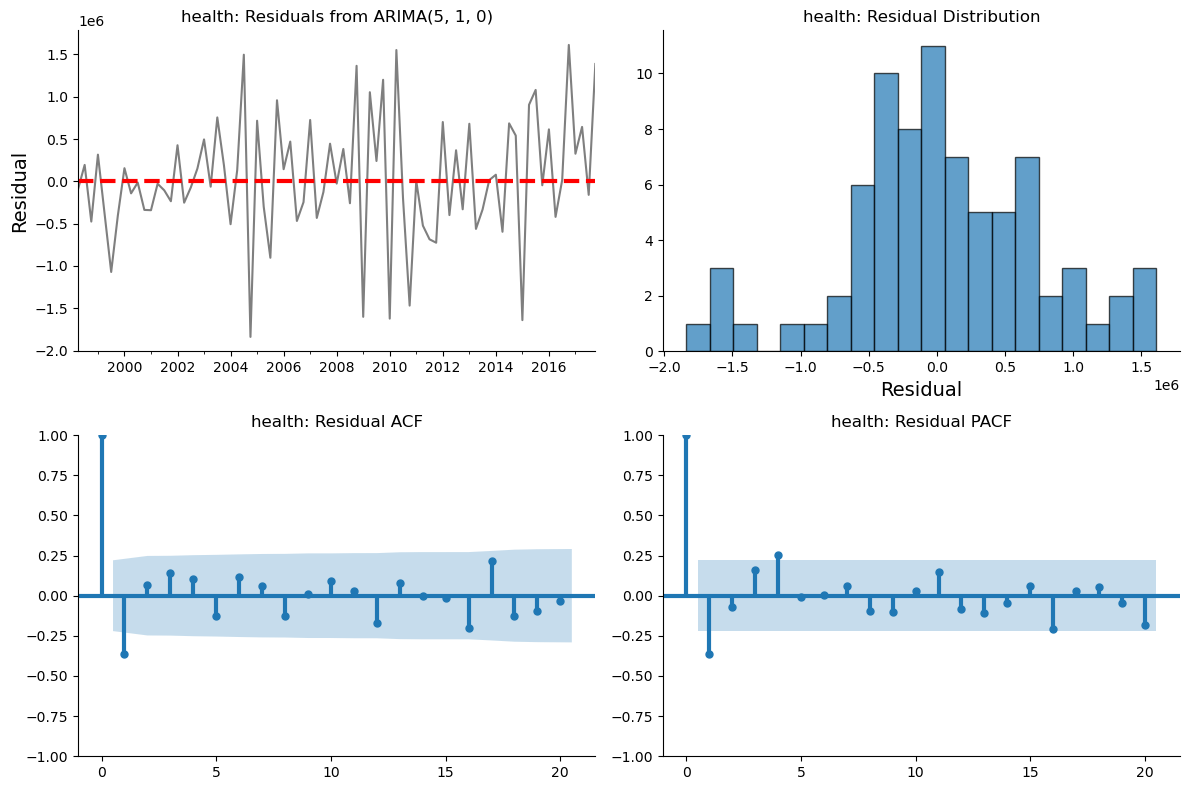

RESIDUALS FOR PROF_SVCS INDUSTRY


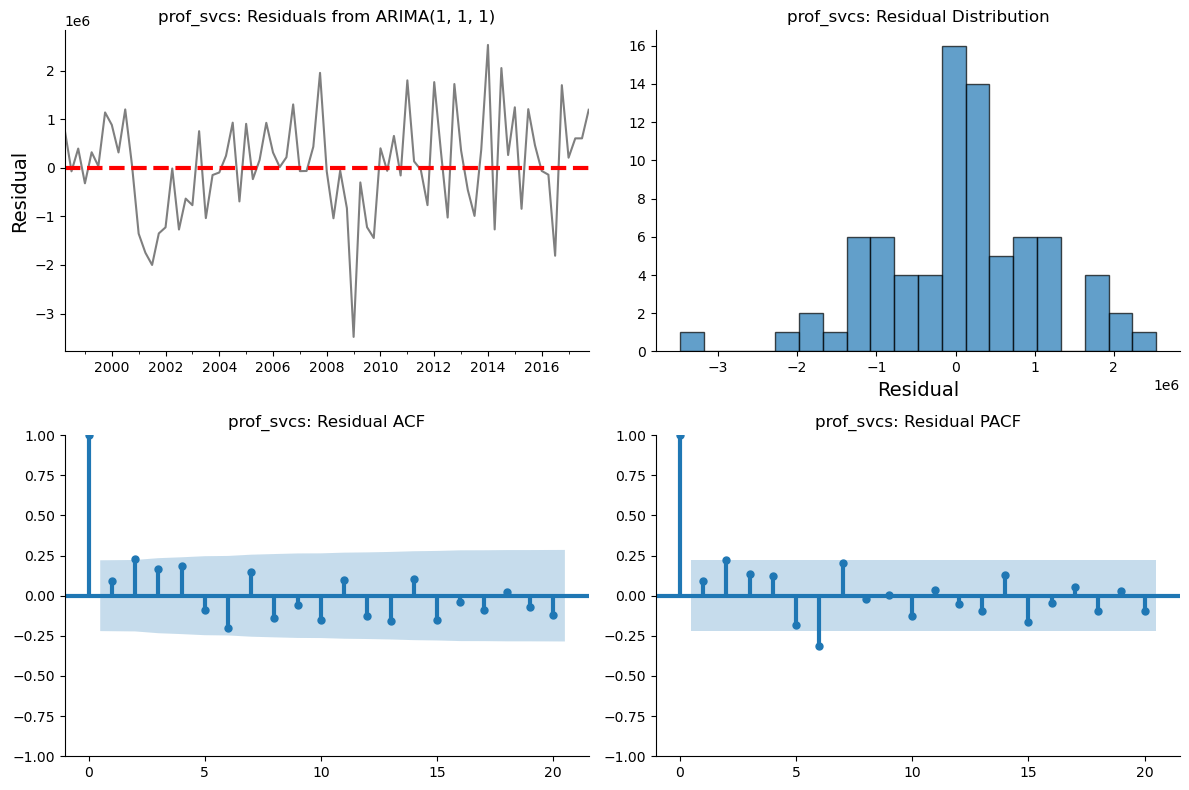

RESIDUALS FOR TECH INDUSTRY


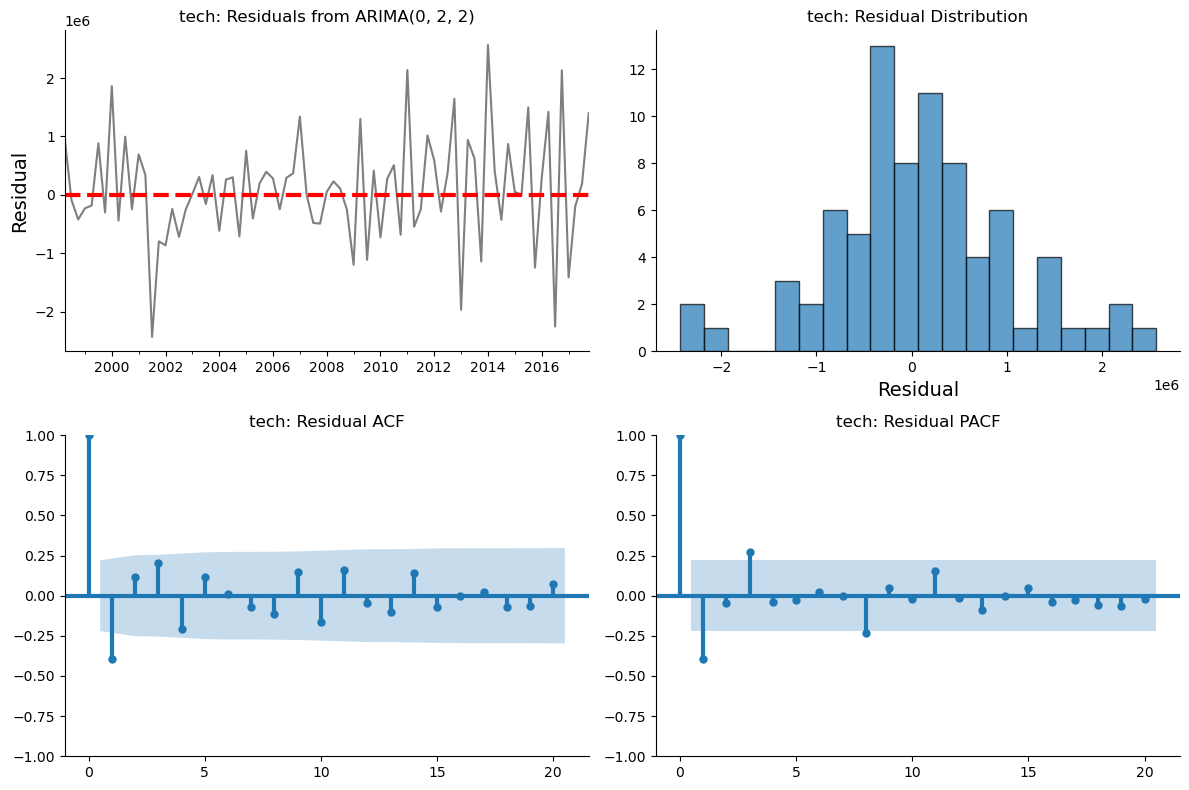

In [232]:
for s_label, model in arima_models.items():
    #data selection
    order = chosen_orders[s_label]
    residuals = model.resid.iloc[1:]

    #loop through and make residual plots
    print(f'RESIDUALS FOR {s_label.upper()} INDUSTRY')
    print('='*100)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    residuals.plot(
        ax=axes[0, 0],
        color='tab:gray',
        linewidth=1.5
    )
    axes[0, 0].axhline(0, color='red', linestyle='--')
    axes[0, 0].set_title(f'{s_label}: Residuals from ARIMA{order}')
    axes[0, 0].set_ylabel('Residual')

    axes[0, 1].hist(
        residuals,
        bins=20,
        edgecolor='black',
        alpha=0.7,
        color='tab:blue'
    )
    axes[0, 1].set_title(f'{s_label}: Residual Distribution')
    axes[0, 1].set_xlabel('Residual')

    plot_acf(residuals, lags=20, ax=axes[1, 0])
    axes[1, 0].set_title(f'{s_label}: Residual ACF')

    plot_pacf(residuals, lags=20, ax=axes[1, 1], method='ywm')
    axes[1, 1].set_title(f'{s_label}: Residual PACF')

    plt.tight_layout()
    plt.show()
    
    print('='*100)

## Random Forest Modeling

### Feature Engineering

In [323]:
def build_features(series, lags=(1, 2, 3, 4, 8, 12)):
    log_series = np.log(series)
    log_diff_series = log_series.diff()

    out = pd.DataFrame({'y': log_diff_series}, index=series.index)

    for L in lags:
        out[f'lag_{L}'] = log_diff_series.shift(L)

    out['quarter'] = out.index.quarter #type: ignore
    out['quarter_sin'] = np.sin(2 * np.pi * out['quarter'] / 4)
    out['quarter_cos'] = np.cos(2 * np.pi * out['quarter'] / 4)

    prior = log_diff_series.shift(1)

    out['4q_mean_diff'] = prior.rolling(4).mean()
    out['4q_std_diff'] = prior.rolling(4).std()
    out['yoy_diff'] = log_diff_series.shift(4)

    return out.dropna()


def make_next_features(history, next_date, lags=(1, 2, 3, 4, 8, 12)):
    log_history = np.log(history)
    log_diff_history = log_history.diff()
    row = {}

    for L in lags:
        row[f'lag_{L}'] = log_diff_history.iloc[-L]

    quarter = next_date.quarter
    row['quarter'] = quarter
    row['quarter_sin'] = np.sin(2 * np.pi * quarter / 4)
    row['quarter_cos'] = np.cos(2 * np.pi * quarter / 4)

    prior = log_diff_history.dropna()

    row['4q_mean_diff'] = prior.iloc[-4:].mean()
    row['4q_std_diff'] = prior.iloc[-4:].std()
    row['yoy_diff'] = log_diff_history.iloc[-4]

    return pd.DataFrame(row, index=[next_date])


def recursive_rf_forecast(model, train_series, forecast_index, lags=(1, 2, 3, 4, 8, 12)):
    history = train_series.copy()
    level_preds = []

    for date in forecast_index:
        X_next = make_next_features(history, date, lags=lags)

        log_diff_pred = model.predict(X_next)[0]
        next_level = history.iloc[-1] * np.exp(log_diff_pred)

        level_preds.append(next_level)
        history.loc[date] = next_level

    return pd.Series(level_preds, index=forecast_index, name='forecast')


def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return pd.Series(
        {
            'MAE': mae,
            'RMSE': rmse,
            'MAPE_pct': mape,
            'R2': r2
        },
        name=name
    )

### Model Fit/Train

In [324]:
#Tree-based models

#storage
rf_models = {}
dt_models = {}
rf_forecasts = {}
dt_forecasts = {}
naive_forecasts = {}
rf_evals = {}

#series forecsating loop
for s in series_list:
    s_label = s.name

    train_series = s.iloc[:-test_length]
    test_series = s.iloc[-test_length:]

    rf_feature_matrix = build_features(train_series)

    X_train = rf_feature_matrix.drop(columns=['y'])
    y_train = rf_feature_matrix['y']

    dt = DecisionTreeRegressor(
        max_depth=5,
        min_samples_leaf=3,
        random_state=42
    )

    rf = RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=3,
        max_depth=5,
        random_state=42
    )

    dt.fit(X_train, y_train)
    rf.fit(X_train, y_train)

    forecast_index = test_series.index

    rf_pred_lvls = recursive_rf_forecast(
        rf,
        train_series,
        forecast_index
    )

    dt_pred_lvls = recursive_rf_forecast(
        dt,
        train_series,
        forecast_index
    )

    naive_lvls = pd.Series(
        train_series.iloc[-1],
        index=test_series.index,
        name='naive'
    )

    rf_models[s_label] = rf
    dt_models[s_label] = dt

    rf_forecasts[s_label] = rf_pred_lvls
    dt_forecasts[s_label] = dt_pred_lvls
    naive_forecasts[s_label] = naive_lvls

    rf_evals[s_label] = pd.concat(
        [
            evaluate('Random Forest', test_series, rf_pred_lvls),
            evaluate('Decision Tree', test_series, dt_pred_lvls),
            evaluate('Naive', test_series, naive_lvls)
        ],
        axis=1
    ).T

### Error Evaluation

In [325]:
for key, item in rf_evals.items():
    print(f'Error Metrics for {key.upper()} Industry')
    print(item)
    print('='*50)

Error Metrics for FINANCE Industry
                        MAE          RMSE  MAPE_pct        R2
Random Forest  1.634265e+07  1.830813e+07  0.088814 -0.808673
Decision Tree  2.541219e+07  2.968787e+07  0.136886 -3.755869
Naive          2.492502e+07  2.840033e+07  0.133599 -3.352299
Error Metrics for HEALTH Industry
                        MAE          RMSE  MAPE_pct        R2
Random Forest  3.963019e+06  4.729736e+06  0.028319  0.880786
Decision Tree  7.465281e+06  8.679316e+06  0.053480  0.598557
Naive          1.937965e+07  2.355145e+07  0.136817 -1.955888
Error Metrics for PROF_SVCS Industry
                        MAE          RMSE  MAPE_pct        R2
Random Forest  7.786248e+06  8.117608e+06  0.063123  0.308014
Decision Tree  8.944249e+06  1.135608e+07  0.069851 -0.354248
Naive          2.155631e+07  2.366223e+07  0.171895 -4.879669
Error Metrics for TECH Industry
                        MAE          RMSE  MAPE_pct        R2
Random Forest  5.289679e+06  5.622184e+06  0.087962 -0.4

### Forecast Visualization

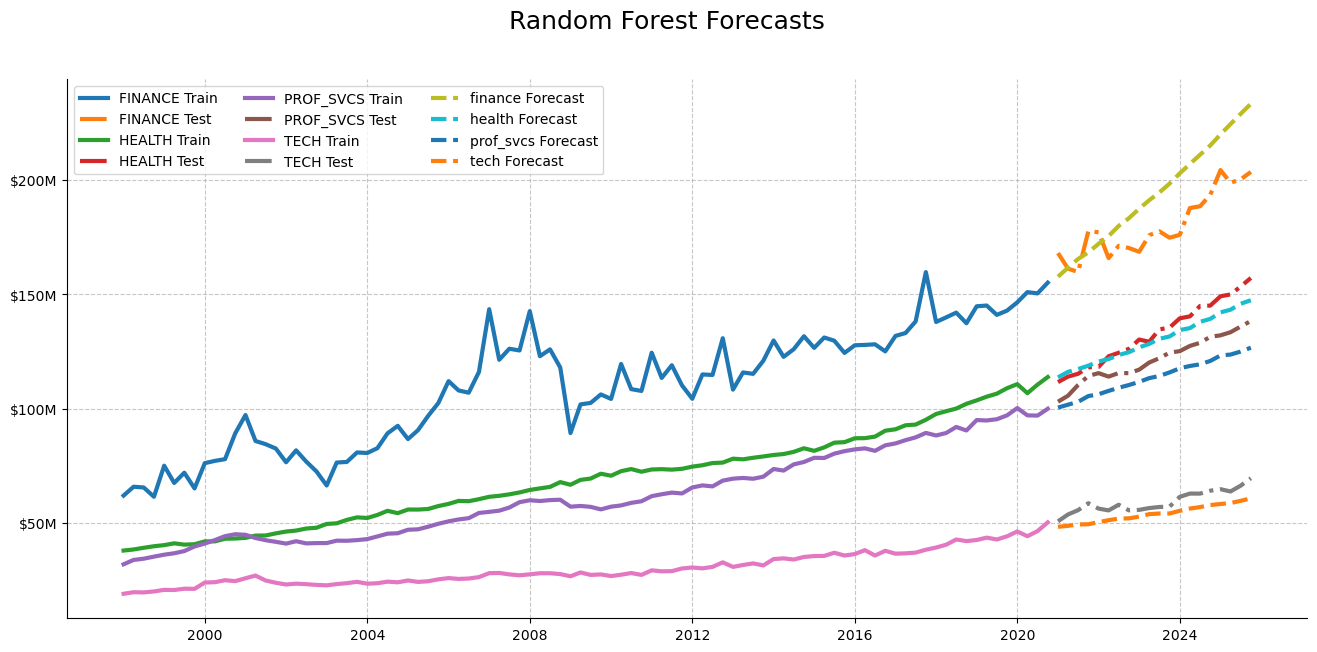

In [327]:
rf_fc_df = pd.DataFrame(rf_forecasts)
plt.figure(figsize=(16,7))
for series in series_list:
    series_label = series.name.upper() #type: ignore
    plt.plot(series.iloc[:-test_length],
             label=f'{series_label} Train') 
    plt.plot(series.iloc[-test_length:],
             label=f'{series_label} Test',
             linestyle='-.')

for col in rf_fc_df.columns:
    plt.plot(rf_fc_df[col],
             linestyle='--',
             label=f'{col} Forecast')
    
plt.gca().yaxis.set_major_formatter(million_form)
plt.legend(ncols=3)
plt.grid()
plt.suptitle('Random Forest Forecasts')
plt.show();

___
# Dashboard

In [328]:
import plotly.express as px
import streamlit as st

In [ ]:
# get the best models for each type

finance_models = {
    'ETS':,
    'ARIMA':,
    'Random Forest':
}

health_models = {
    'ETS':,
    'ARIMA':,
    'Random Forest':
}


prof_svcs_models = {
    'ETS':,
    'ARIMA':,
    'Random Forest':
}


tech_models = {
    'ETS':,
    'ARIMA':,
    'Random Forest':
}

In [ ]:
#generate forecast data



In [ ]:
#generate residual data

In [ ]:
#calculate the errors

In [ ]:

#App layout

row1, row2 = st.rows(2)

filter_selection = ['Finance',
                    'Health care',
                    'Professional/Technical services',
                    'Technology']

st.selectbox(label='Industry',
             options=filter_selection)
st.date_input(label='Start Date')
st.number_input(label='Forecast Horizon')

with row1:
    st.header('Time Series')
    #interactive plotly lineplot that displays the selected industry based on the user selections
    
    #line plot 1 to show actuals
    #line plot 2 to show ETS model
    #line plot 3 to show ARIMA model
    #line plot 4 to show Random Forest model

with row2:
    col1, col2 = st.cols(2)

    with col1:

        #residual visualzations showing the distribution and a plot of the residuals
    
    with col2:
        #model error metrics
        #a simple table showing the error metrics for the selected models
        # error metrics should include MAE, MAPE, R2
